In [1]:
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns
import sqlite3

#import database
conn=sqlite3.connect('customer_churn.db')
#make connection from sql database
sql_query="""
    select name
    from sqlite_master
    where type='table';

"""
tables=pd.read_sql(sql_query,conn)

for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f'df_{table_name}']=df
    print(f"database created:{table_name}")

conn.close()

#print table names and columns

# Print table names and column names       BY THE HELP OF PRAGMA
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()

database created:db_customer
database created:db_subscription
database created:db_support

Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [2]:
#DATA CLEANING
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [3]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [4]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [5]:
#a.drop columns interest and pincode
#b.rename column name to customer_column
#c.change dob data type
#d.country missing value
#e.data standardisation in Gender

# by watching info and head and tail


In [6]:
#rename
#df_db_customer.rename(columns={'name':'customer_name'})
#upper wale se bas temporary rename hoga to make it permanent inplace=true karna hoga
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)


In [7]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [8]:
#b.drop 2 columns interest and pincode

In [9]:
#first method:index basis
df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
#column ke liye axis=1 and row ke liye 0
#last 2 columns


,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [10]:
#second method: name
df_db_customer.drop(columns=['interests','pincode'],inplace=True)


In [11]:
#c.change data type
pd.to_datetime(df_db_customer['dob'])

0    1982-04-12
1    1995-11-23
2    1978-02-15
3    2001-08-30
4    1990-05-05
5    1988-12-10
6    1976-09-21
7    1999-03-14
8    1985-07-07
9    1993-10-29
10   1997-01-22
11   1981-06-18
12   2004-12-01
13   1992-04-25
14   1979-11-11
15   1986-02-28
16   1994-08-19
17   2000-09-02
18   1983-12-30
19   1991-05-14
20   1977-10-06
Name: dob, dtype: datetime64[ns]

In [12]:
#if not using inplace
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [13]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [14]:
#d. standardisation - gender
#HOW TO CHECK ONE OF THE METHODS.UNIQUE
df_db_customer['gender'].unique()


array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [15]:
#replace value
df_db_customer['gender'].replace({'Men':'Male','Women':'Female'},inplace=True)

C:\Users\gupta\AppData\Local\Temp\ipykernel_17472\2612564137.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['gender'].replace({'Men':'Male','Women':'Female'},inplace=True)


In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [17]:
#e.fix missig value-country
df_db_customer['country'].isna()
#find you values where value is null


0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [18]:
#to find which column is null just df_db_customer[put is na line here]
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [19]:
#check earlier pair and replace by that
#.fillna()  replace the null value here
#but here we will do pair check and replace
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [20]:
#yaha pe chal gaya but not necessary
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [21]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [22]:
df_db_customer


,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [23]:
#to check whether na values are still there or not
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [24]:
#SUBSCRIPTION TABLE

In [25]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,None,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,None,None,6.99,335,41


In [26]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [27]:
#date wale ko fixed karna hain
date_col=['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [28]:
#CUSTOMER_SUPPORT

In [29]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [30]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 560.0+ bytes


In [31]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)


In [32]:
#datetime conversion
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 416.0+ bytes


In [33]:
#FEATURE ENGINEERING AND DATA ANALYSIS

In [34]:
#CREATE A NEW TABLE FROM ANOTHER TABLE

In [35]:
#churn rate:rate at which user leaves platform
#lets make churn flag:where subsription cancelled it gives 1 otherwise 0

df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [36]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [37]:
#WE WILLJOIN NEW DATA so as tp accesss everything

df_db_subscription.merge(df_db_customer,on='customerid',how='left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29


In [38]:
#one more merge
#multi[le merge pe parenthesis lagana padega

df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left')
 )

In [39]:
#VERYYYYYYYYYYYYYYYYYYYY
#IMPORTANT
#CHECK ROWS AND COLUMNS

df_db_subscription.shape

(21, 12)

In [40]:
df.shape

(23, 20)

In [41]:
#PROBLEM EXTRA ROWS KAHA SE AAYIIIIIIIIIII

In [42]:
#HOW TO SOLVE
#1.check unique and clean records
df_db_subscription['customerid'].nunique()

21

In [43]:
df_db_customer['customerid'].nunique()

21

In [44]:
df_db_support['customerid'].nunique()

7

In [45]:
df_db_support['customerid'].size

9

In [46]:
#SUPPORT ME DIKKAT HAIN
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [47]:
#0 and 1 id are same
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [48]:
#let's fix this

df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [49]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [51]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')
#keep=last se last value ko rakhega when spots similar entries

In [52]:
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left')
 )

In [54]:
df.shape

(21, 21)

In [56]:
df.to_csv('exported_churn_data.csv',index=False)

In [55]:
#DATA ANALYSIS

In [57]:
#1.Churn rate

In [58]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [63]:
churn_rate=df['churn_flag'].mean()*100
churn_rate
#28% users are churned

28.57142857142857

In [66]:
#2.retention rate
retention_rate=100-churn_rate
retention_rate 

71.42857142857143

In [67]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [70]:
#3.which plan type users left platform
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
#churn flag column ke basis par we are grouping

In [71]:
#basic wale are most here
churn_by_plan

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [ ]:
#4 a.churn by state + sum of revenue and count of users
#4 b.churn by subscription type + sum of revenue and count of users

df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index()


,state,churn_flag
0,Delhi,25.00
1,Karnataka,100.00
2,Kathmandu,0.00
3,Maharashtra,0.00
4,Meghalaya,66.67
5,Nagaland,0.00
6,Rajasthan,0.00
7,Telangana,50.00
8,Uttar Pradesh,0.00


In [75]:

df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index()

,subscription_type,churn_flag
0,Organic,0.00
1,Paid,16.67
2,Refferal,83.33


In [81]:
#5.ARPU: AVERAGE REVENUE PER USER

arpu=df['monthly_charges'].mean()
print('ARPU',round(arpu,2))

ARPU 18.85


In [83]:
#6.number of days till cancelled or contiuing subscription
#  AVERAGE CONSUMER TENURE

today=pd.Timestamp.today()
today

Timestamp('2026-08-30 12:20:29.005391')

In [85]:
df['tenure_days']=np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days
    ,(today-df['subscription_start_date']).dt.days


)
df


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1994.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1379.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2669.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0,1534.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0,1142.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN,2389.0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN,1135.0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN,1610.0


In [87]:
avg_tenure=df['tenure_days'].mean()
avg_tenure

1528.0

In [ ]:
#7.revenue at risk from churn users
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revenue at risk(in thousands)",revenue_at_risk)

revenue at risk(in thousands) 73.94


In [92]:
#8.Escallation rate:complaining one more time after once not solved
escallation_rate=(df['escalations']=='Y').mean()*100
print("Escalation rate:")
escallation_rate

Escalation rate:


19.047619047619047

In [93]:
#9.Avg Complaint per user

In [97]:
avg_complaint_rate=(df['complaint_count'].sum()/df['customerid'].nunique())*100
print("average complaint per user")
avg_complaint_rate

average complaint per user


42.857142857142854

In [ ]:
df['complaint_count'].sum()   #sir ka 7 tha

9.0

In [99]:
#10.correlation  Escalations vs Churn

In [100]:
df[['escalations','churn_flag']]

,escalations,churn_flag
0,NaN,0
1,Y,1
2,NaN,0
3,NaN,0
4,Y,1
5,N,0
6,N,1
7,NaN,0
8,NaN,0
9,NaN,0


In [102]:
df[['customerid','escalations','churn_flag']].dropna()

,customerid,escalations,churn_flag
1,0003-MKNFE,Y,1
4,0013-EXCHZ,Y,1
5,0013-MHZWF,N,0
6,0013-SMEOE,N,1
11,0017-IUDMW,Y,1
13,0019-EFAEP,Y,1
18,0022-TCJCI,N,1


In [ ]:
#for fast calculation change y and nto 0 and1

df['escalations']=np.where(df['escalations']=='Y',1,0) # encoding strng to int type

In [105]:
df['escalations']

0     0
1     1
2     0
3     0
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    0
19    0
20    0
Name: escalations, dtype: int32

In [107]:
#finding correlation
corr_df=df[['escalations','churn_flag']].dropna()
correlation=corr_df['escalations'].corr(df['churn_flag'])
print("correlation between escalations and churn flag :",round(correlation,2))

correlation between escalations and churn flag : 0.77


In [110]:
#11.Churn_risk
df['churn_score'].head()

conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choices=['low','mid','high']
df['churn_risk']=np.select(conditions,choices,default='unknown')

In [112]:
df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [113]:
#DATA VISUALIZATION USING MATPLOTLIB AND SEABORN

In [114]:
#COPY
df_visual=df.copy()

In [122]:
#4.1 monthly churn trend(time series kpi)
df_visual['cancellation_month']=df['cancellation_date'].dt.to_period('M')
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
churn_trend


cancellation_month
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64

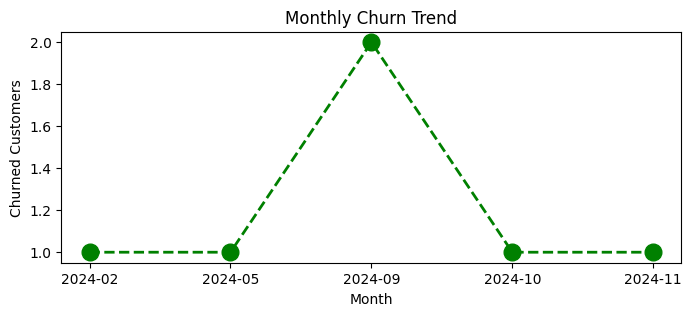

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()


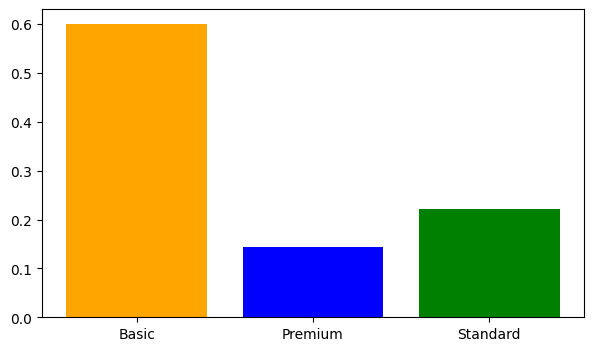

In [131]:
#4.2 churn by plan type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
color=['orange','blue','green']
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=color)
plt.show()

In [132]:
#dynamic color allocation:colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

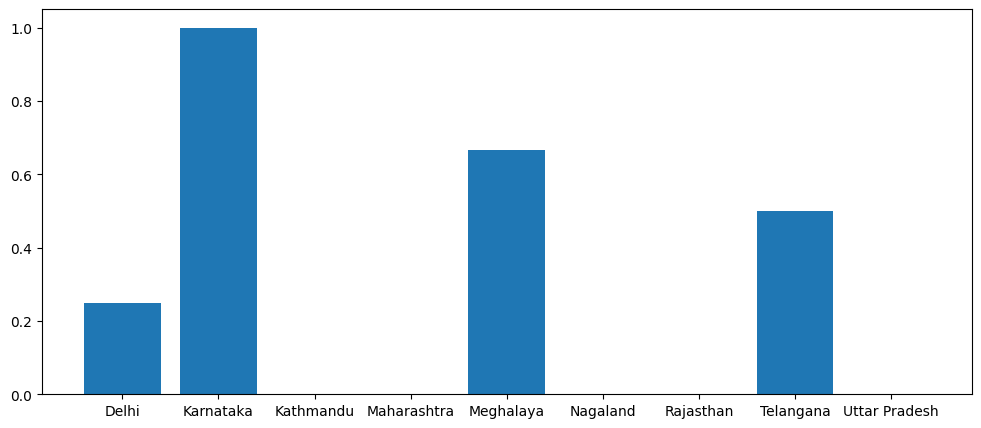

In [136]:
#4.3churn by states
churn_plan=df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,5))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

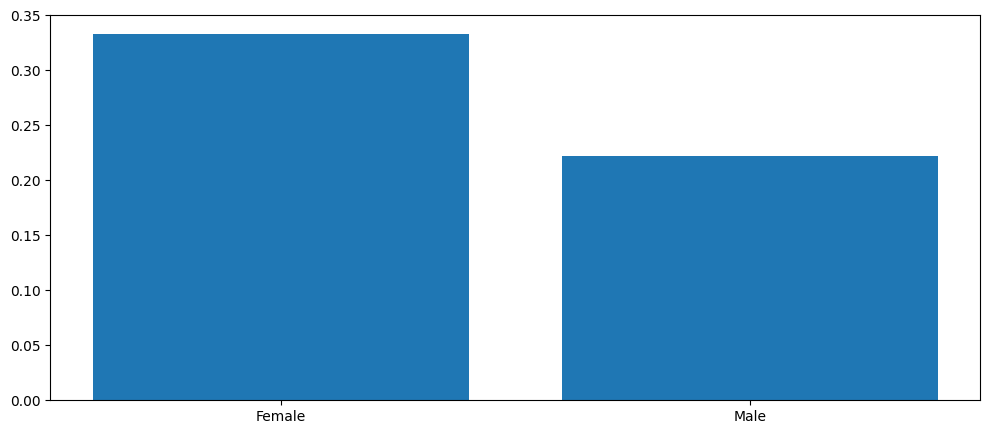

In [137]:
gender_plan=df_visual.groupby('gender')['churn_flag'].mean()
plt.figure(figsize=(12,5))
plt.bar(gender_plan.index,gender_plan.values)
plt.show()

In [138]:
#SEABORNNNNNN

In [144]:
#1.HEATMAP
#sns.heatmap()
df_encoded=df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]
#encoding everything into numbers so that we can easily compare

In [146]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [148]:
categorical_cols=df[['plan_type','contract_type','churn_risk']]

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes
#.cat.codes helps to change categorical to numerical

<Axes: >

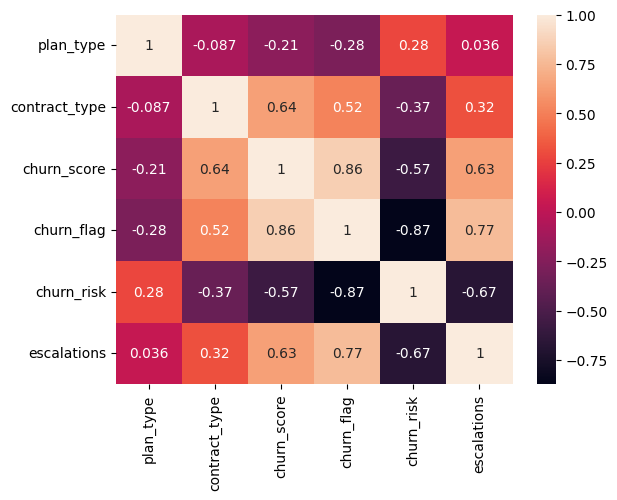

In [149]:
sns.heatmap(df_encoded.corr(),annot=True)

In [151]:
#problem is churn flag and churn risk are negatively correlated but they should be positively related 
#many are wrong

In [152]:
#because number jo alot hue hai vo random hai isliye correlation is rubish for now

In [153]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

<Axes: >

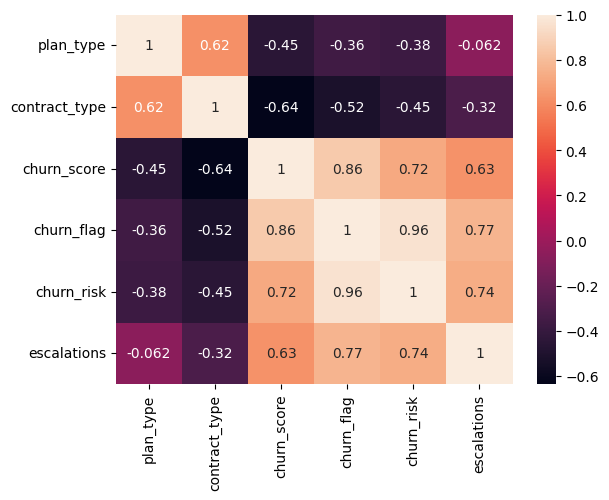

In [154]:
sns.heatmap(df_encoded.corr(),annot=True)

In [155]:
#heatmap using matplotliib is very difficult as it is very long

In [ ]:
#PAIRPLOT: 2 value ke bich me comparison

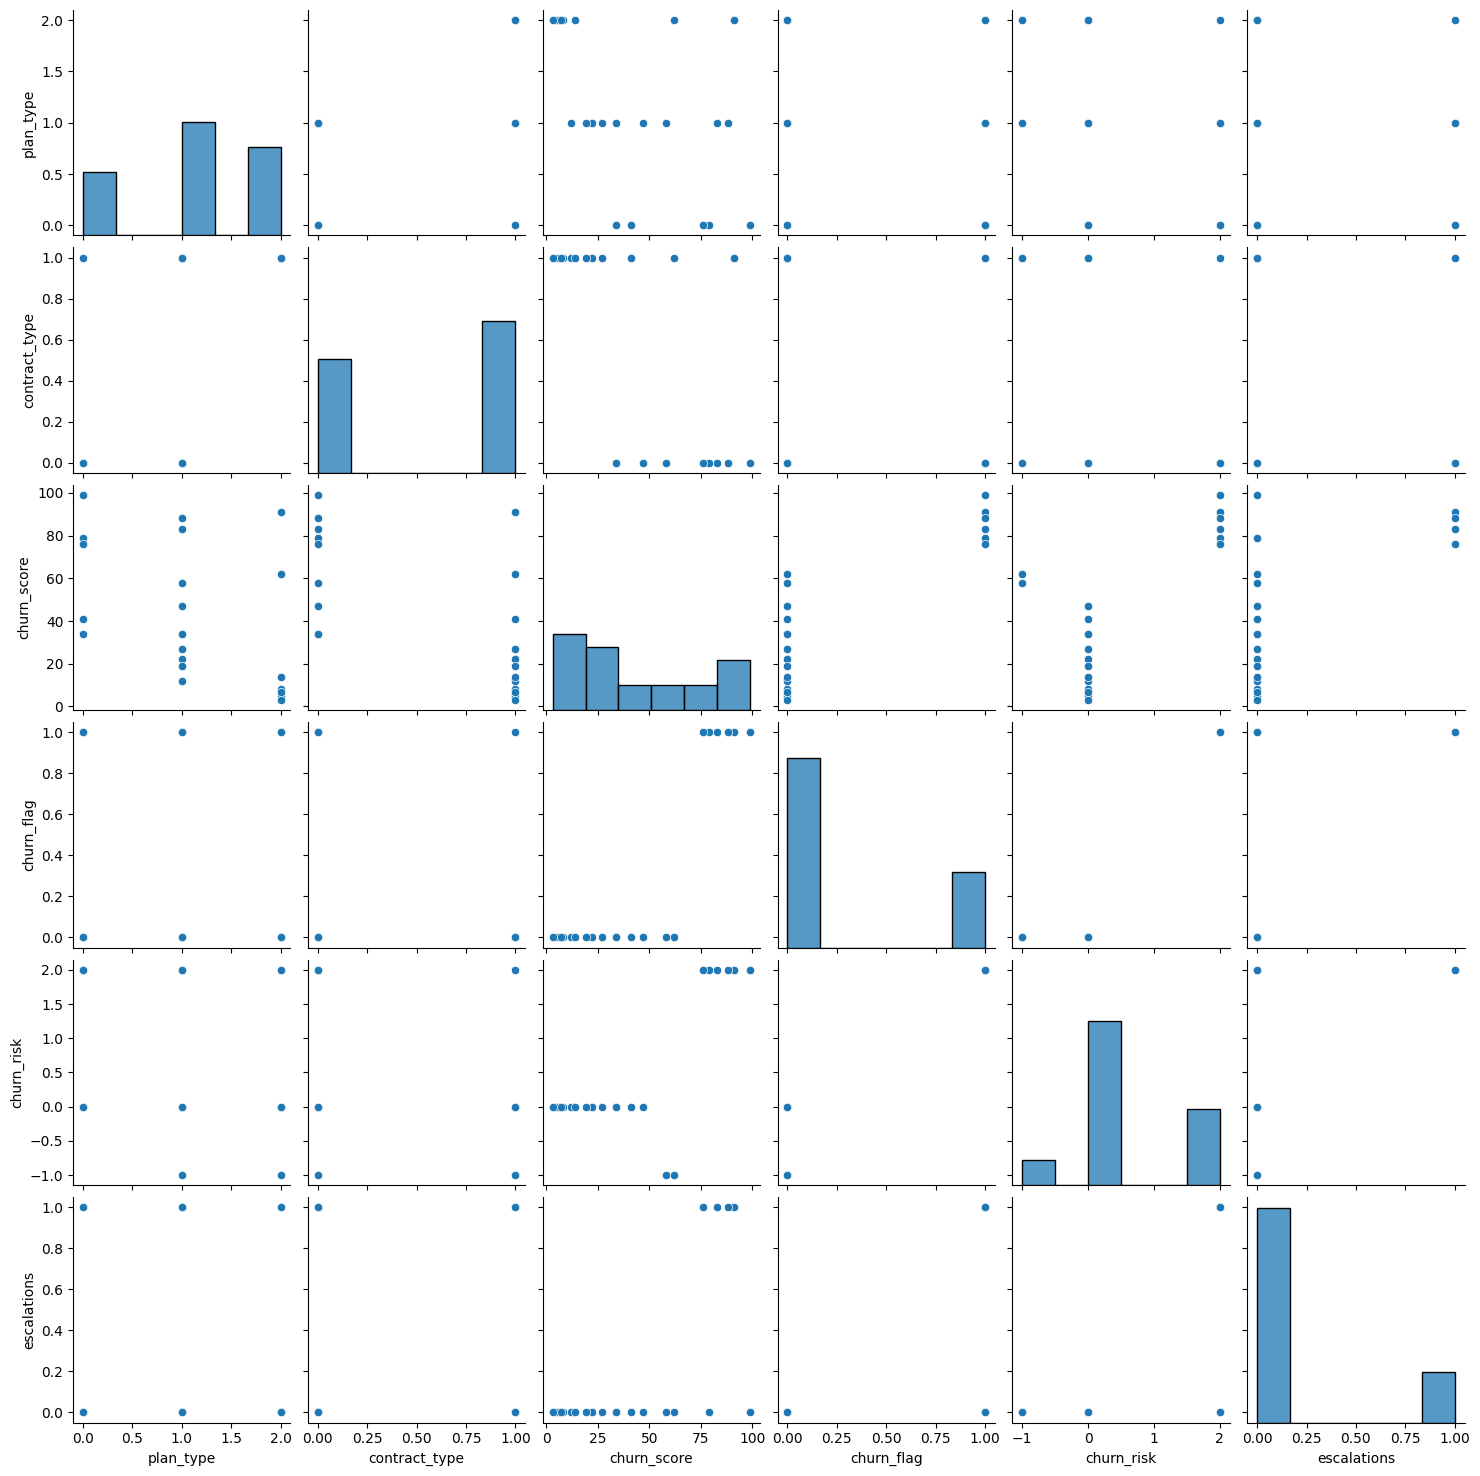

In [157]:
sns.pairplot(df_encoded)

In [ ]:
#CATEGORICAL CHART:multiple dimension comparison

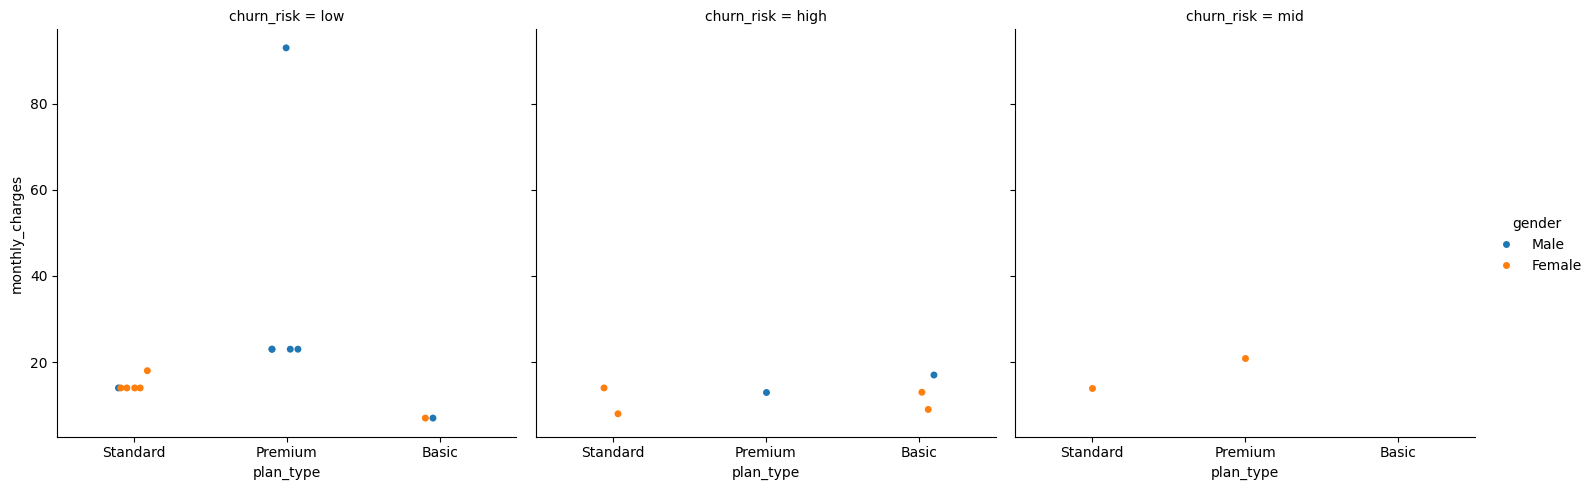

In [162]:
sns.catplot(data=df_visual,
x='plan_type',
y='monthly_charges',
hue='gender',
col='churn_risk'
)
#ye ek baar learn karna

In [163]:
#pivot table

In [166]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'


)#always type shift tab for help

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [171]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    }



)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [172]:
#working with sql in python(pandas)

In [173]:
#create db in sql
conn=sqlite3.connect('test_database.sqlite')

#table details:YAHA PE DATATYPE DIFFERENT HOTE HAIN
conn.execute("CREATE TABLE users (first_name TEXT,country TEXT,budget INTEGER)")

#COMMIT AND SAVE
conn.commit()

In [174]:
#insert data
cursor=conn.cursor()

cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav','India',5000),
            ('Rishabh','Germany',3500)
        
    """
)
conn.commit()
print("done")

done


In [175]:
#check inserted data in table
conn=sqlite3.connect('test_database.sqlite')
query="""
    SELECT * from users
"""
df_results=pd.read_sql(query,conn)
df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,3500


In [176]:
#aggregation

query="""
    SELECT country,sum(budget) as total_budget
    from users
    group by country
"""
df_agg=pd.read_sql(query,conn)
df_agg

,country,total_budget
0,Germany,3500
1,India,5000


In [178]:
conn.close() #good practice

In [180]:
#Portfolio Project – Summary
#• Churn & Revenue Impact (general summary)

#Engineered an end-to-end churn analytics pipeline for an OTT subscription platform by integrating multi-table subscriber data across acquisition type, contract structure, and plan tier (20+ KPIs). Uncovered a significant churn disparity between monthly and annual contract segments, quantified MRR leakage and CLTV erosion attributed to high-risk cohorts, and delivered a data-backed contract-migration retention strategy to reduce involuntary subscriber loss.

#• Risk Scoring & Segmentation (Risk Analysis & Segmentation)

#Developed a multi-dimensional churn risk scoring model by synthesising subscription tenure, plan type, and support escalation signals across three relational tables (20+ KPIs), segmented the customer base into risk tiers using composite churn scores, exposed a significant lifetime value gap between churned and retained cohorts, and recommended prioritising Premium annual-plan retention over Basic monthly acquisition to maximise long-term revenue yield.

#• Support Intelligence & Cancellation Analysis (working on live data)

#Performed cross-functional support-churn correlation analysis by joining complaint, escalation, and cancellation subscription records, identified that escalated support interactions were disproportionately concentrated among high-risk customers, decomposed cancellation drivers into competitor switching, pricing sensitivity, and content-related factors, and translated findings into a prioritised product and pricing roadmap presented to the platform's growth team.

In [181]:
#Portfolio Project – Summary
#• Churn & Revenue Impact (general summary + with numbers from dataset)

#Engineered an end-to-end churn analytics pipeline for an OTT subscription dataset (20+ KPIs), identifying a 28.6% overall churn rate and surfacing that monthly-contract subscribers churned at 55.6%, which is 6.7 times the 8.3% annual-contract rate—directly attributing $73.94/mo in MRR leakage and $2,047 in CLTV erosion to six at-risk customers, enabling a targeted contract-migration retention strategy.